# Module 8 - Final Project 


**In this final project, you will demonstrate what you have learned in this class by applying a thorough data analysis to a data set of your choice.** 

As discussed on the discussion boards in the last two weeks, your data set should contain rich enough features and a good sample size so that you can apply the methods you have learned to derive some **insights** from the data. The ultimate goal of data analysis is to learn from the data so that we can form useful and actionable knowledge. 

**Predictive models are only useful if you can interpret the data, find out influential variables, derive insights that are useful and actionable for your audience!**

---

Use this notebook for the analysis of your final project. **Your deliverables for the final project are:** 

- **This notebook**: contains the **full** data science project life cycle as you have learned in the Intro class. 
 
   - Load your data, clean your data, include all the carpentry you need to put it into some shape for your later analysis. 
            
  - EDA: exploratory data analysis: this is where you do the univariate and multivariate analyses; visualize your data to understand the shape and associations in it. Plot densities, histograms, scatter plots, etc. Look for correlations, patterns, clusters, etc.     
   
  - Modeling and hypothesis testing: use any of the adequate techniques to see if you can model the influence of the variables on each other. You can try to reduce dimensionality, try to do regression analysis, hypothesis testing, etc. to see how variables affect each other.    
   
  - **Insights:** the point of data analysis to derive **insights** from your data. What do you see? What did you learn from the data? Did it answer your initial question or did it verify your hypothesis? 
   
   
- **A PDF file** that contains a **few** slides to summarize your results: similar to the data vis course, create a pdf document that contains up to 4-5 slides (**no more**) to present your results. Make sure to put the pdf file **in the `exercises` folder of module 8**. Communicate your results effectively using visualization principles you have learned and provide useful and actionable insights for your audience. 
 
 
 
- Upload your data set to this folder (under exercises folder). 
 
 ---
 
 
 **You should have ample explanation and comments for all your data analysis in this notebook.** Think of it as a LAB notebook: imagine that you are creating a lab notebook for others to follow and learn from your analysis. You should have enough details so that somebody can recreate your analysis by following your descriptions and explanations. 
 
Have a markdown cell before each code cell explaining **what** you are doing and **why** you are doing it. Have comments in the code cell. Have a markdown cell **after** every code cell explaining what you just found out by running that code cell before. 
 
 ---
 
 

## Problem Definition & Research Context

###  Project Title  
**Analyzing Operational Drivers of Team Productivity in Garment Manufacturing**

###  Dataset  
Productivity Prediction of Garment Employees

Source: UCI Machine Learning Repository - https://archive.ics.uci.edu/dataset/597/productivity+prediction+of+garment+employees
 
Each row = one production team's performance for a single day (team-day).  
This includes operational metrics (overtime, idle time, workers), incentive data, and productivity outcomes.

---

###  Purpose and Audience
This project identifies the key operational factors that influence team productivity in garment manufacturing.

**Primary audience:**  
- Factory Operations Managers  
- HR & Productivity Analysts

**Why it matters:**  
This analysis will provide insights to help optimize:  
- Overtime planning  
- Incentive strategy  
- Workflow allocation  

---

### Research Questions
1. How do overtime, idle time, incentives, and team size impact actual productivity?
2. Do department (sewing vs finishing) or day type (weekday vs weekend) influence productivity differences?
3. Can PCA/FA combine correlated operational variables into meaningful “efficiency” components?

---

###  Hypotheses
- **H₁:** Overtime increases productivity, but with diminishing returns.  
- **H₂:** Idle time has a non-linear effect — too little or too much reduces productivity.  
- **H₃:** Incentives are positively associated with productivity (up to an effective limit).  
- **H₄:** Productivity varies across departments and day types.  
- **H₅:** PCA/FA components will reveal latent operational factors like workload intensity and efficiency.
 

## 1. Loading, Cleaning, Displaying Data 

Explain your data set here; 

 - what is it about? 
 
 - What are the variables? 
 
 - What do you want to do with it? (your research questions or hypotheses if you have any) 
 
 - How are you going to clean it? etc. 


In this section, I will load the **Garment Employee Productivity** dataset and perform all the initial data-preparation steps.  
The purpose is to understand what the dataset contains, verify variable types, check for missing or out-of-range values,  
and ensure the data are clean and properly formatted for later analysis.

---

###  About the Dataset  
The dataset records team-level daily productivity from a garment factory in Bangladesh.  
Each observation represents one team’s performance for a single day.  
The data include both operational variables (like overtime and idle time) and workforce attributes (like department and incentives).  
Source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/597/productivity+prediction+of+garment+employees)

---

###  Key Variables  

| Variable | Type | Description |
|-----------|------|-------------|
| `actual_productivity` | Continuous (0–1) | Achieved productivity of the team |
| `targeted_productivity` | Continuous (0–1) | Planned target productivity |
| `overtime` | Continuous | Extra minutes worked beyond schedule |
| `incentive` | Continuous | Bonus or reward value |
| `idle_time` | Continuous | Percentage of lost time due to stoppages |
| `idle_men` | Continuous | Number of idle workers |
| `no_of_workers` | Continuous | Total workers in the team |
| `smv` | Continuous | Standard Minute Value (workload measure) |
| `wip` | Continuous | Work in progress count |
| `department` | Categorical | Type of department (Sewing / Finishing) |
| `day` | Categorical | Day of the week (Mon–Sun) |
| `team` | Categorical | Team identifier (1–12) |
| `quarter` | Categorical | Fiscal quarter (Q1–Q4) |

---

###  Data-Cleaning Plan  
1. Verify that `actual_productivity` and `targeted_productivity` are within [0, 1].  
2. Check for missing or duplicate records.  
3. Convert variables to the correct data types (categorical vs numeric).  
4. Handle missing values—drop if < 2 %, otherwise impute with the median.  
5. Create a clean, analysis-ready dataset for further steps.

In [1]:
# # Step 1.1 - Load the dataset and inspect its structure

library(tidyverse)

df <- read.csv("garments_worker_productivity.csv")

dim(df)         

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.3     ✔ purrr   0.3.4
✔ tibble  3.1.1     ✔ dplyr   1.0.6
✔ tidyr   1.1.3     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



[1] 1197   15

In [2]:
head(df, 10)       

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108,7080,98,0,0,0,59.0,0.9407254
2,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NA,960,0,0,0,0,8.0,0.8865000
3,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968,3660,50,0,0,0,30.5,0.8005705
4,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968,3660,50,0,0,0,30.5,0.8005705
5,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170,1920,50,0,0,0,56.0,0.8003819
6,1/1/2015,Quarter1,sweing,Thursday,7,0.80,25.90,984,6720,38,0,0,0,56.0,0.8001250
7,1/1/2015,Quarter1,finishing,Thursday,2,0.75,3.94,NA,960,0,0,0,0,8.0,0.7551667
8,1/1/2015,Quarter1,sweing,Thursday,3,0.75,28.08,795,6900,45,0,0,0,57.5,0.7536835
9,1/1/2015,Quarter1,sweing,Thursday,2,0.75,19.87,733,6000,34,0,0,0,55.0,0.7530975


In [3]:
str(df)           

'data.frame':	1197 obs. of  15 variables:
 $ date                 : chr  "1/1/2015" "1/1/2015" "1/1/2015" "1/1/2015" ...
 $ quarter              : chr  "Quarter1" "Quarter1" "Quarter1" "Quarter1" ...
 $ department           : chr  "sweing" "finishing " "sweing" "sweing" ...
 $ day                  : chr  "Thursday" "Thursday" "Thursday" "Thursday" ...
 $ team                 : int  8 1 11 12 6 7 2 3 2 1 ...
 $ targeted_productivity: num  0.8 0.75 0.8 0.8 0.8 0.8 0.75 0.75 0.75 0.75 ...
 $ smv                  : num  26.16 3.94 11.41 11.41 25.9 ...
 $ wip                  : int  1108 NA 968 968 1170 984 NA 795 733 681 ...
 $ over_time            : int  7080 960 3660 3660 1920 6720 960 6900 6000 6900 ...
 $ incentive            : int  98 0 50 50 50 38 0 45 34 45 ...
 $ idle_time            : num  0 0 0 0 0 0 0 0 0 0 ...
 $ idle_men             : int  0 0 0 0 0 0 0 0 0 0 ...
 $ no_of_style_change   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ no_of_workers        : num  59 8 30.5 30.5 56 56 8 57.5 5

In [4]:
summary(df)        

     date             quarter           department            day           
 Length:1197        Length:1197        Length:1197        Length:1197       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
      team        targeted_productivity      smv             wip         
 Min.   : 1.000   Min.   :0.0700        Min.   : 2.90   Min.   :    7.0  
 1st Qu.: 3.000   1st Qu.:0.7000        1st Qu.: 3.94   1st Qu.:  774.5  
 Median : 6.000   Median :0.7500        Median :15.26   Median : 1039.0  
 Mean   : 6.427   Mean   :0.7296        Mean   :15.06   Mean   : 1190.5  
 3rd Qu.: 9.00

In [5]:
# Step 1.1b — Missing values & duplicates ----
cat("\nMissing values by column (proportion):\n")
missing_summary <- colMeans(is.na(df))
print(sort(missing_summary, decreasing = TRUE))


Missing values by column (proportion):
                  wip                  date               quarter 
            0.4227235             0.0000000             0.0000000 
           department                   day                  team 
            0.0000000             0.0000000             0.0000000 
targeted_productivity                   smv             over_time 
            0.0000000             0.0000000             0.0000000 
            incentive             idle_time              idle_men 
            0.0000000             0.0000000             0.0000000 
   no_of_style_change         no_of_workers   actual_productivity 
            0.0000000             0.0000000             0.0000000 


In [6]:
# Step 1.2 — Data carpentry and cleaning 

# Duplicate check
dup_count <- sum(duplicated(df))
cat("\nNumber of duplicate rows:", dup_count, "\n")


Number of duplicate rows: 0 


In [7]:
clean_df <- df %>% distinct()  # remove duplicates if any

In [8]:
clean_df <- clean_df %>% select(-date)

The date column was removed because it does not contribute predictive value for modeling and including it would introduce sparsity and unnecessary noise, potentially reducing model performance.

In [9]:
# Convert columns to factors
categorical_cols <- c("department", "day", "team", "quarter")
clean_df[categorical_cols] <- lapply(clean_df[categorical_cols], as.factor)

In [10]:
# Remove 'wip' due to ~42% missing values
if("wip" %in% names(clean_df)) {
  clean_df <- clean_df %>% select(-wip)
  cat("\nColumn 'wip' dropped due to high missingness (~42%).\n")
}


Column 'wip' dropped due to high missingness (~42%).


In [11]:
# Check numeric columns for out-of-range values in productivity
for (col in c("actual_productivity", "targeted_productivity")) {
  out_range <- clean_df %>%
    filter(.data[[col]] < 0 | .data[[col]] > 1)
  cat(col, ":", nrow(out_range), "out-of-range rows\n")
}

actual_productivity : 37 out-of-range rows
targeted_productivity : 0 out-of-range rows


In [12]:
# Remove rows where actual_productivity is outside [0, 1]
clean_df <- clean_df %>%
  filter(actual_productivity >= 0 & actual_productivity <= 1)

cat("\nDropped out-of-range rows for 'actual_productivity'.\n")
cat("New shape after removing invalid rows:", dim(clean_df), "\n")


Dropped out-of-range rows for 'actual_productivity'.
New shape after removing invalid rows: 1160 13 


In [13]:
# Step 1.3 — Handle missing values 
low_miss <- 0.02   # threshold 2%

for (col in names(clean_df)) {
  miss_ratio <- mean(is.na(clean_df[[col]]))
  if (miss_ratio > 0) {
    if (is.numeric(clean_df[[col]])) {
      if (miss_ratio <= low_miss) {
        # Drop rows if very few missing
        clean_df <- clean_df %>% filter(!is.na(.data[[col]]))
      } else {
        # Impute with median if higher missingness
        clean_df[[col]][is.na(clean_df[[col]])] <-
          median(clean_df[[col]], na.rm = TRUE)
      }
    } else {
      # For categorical: replace NA with 'Missing'
      clean_df[[col]] <- forcats::fct_explicit_na(clean_df[[col]], na_level = "Missing")
    }
  }
}

In [14]:
# Step 1.4 — Final validation ----
cat("\nRe-checked missingness after cleaning:\n")
print(colMeans(is.na(clean_df)))


Re-checked missingness after cleaning:
              quarter            department                   day 
                    0                     0                     0 
                 team targeted_productivity                   smv 
                    0                     0                     0 
            over_time             incentive             idle_time 
                    0                     0                     0 
             idle_men    no_of_style_change         no_of_workers 
                    0                     0                     0 
  actual_productivity 
                    0 


In [15]:
cat("\nFinal dataset dimensions (rows, columns):", dim(clean_df), "\n\n")


Final dataset dimensions (rows, columns): 1160 13 



In [16]:
# Structure and summary of cleaned dataset
library(dplyr)

str(clean_df)
summary(select(clean_df, where(is.numeric)))

'data.frame':	1160 obs. of  13 variables:
 $ quarter              : Factor w/ 5 levels "Quarter1","Quarter2",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ department           : Factor w/ 3 levels "finishing","finishing ",..: 3 2 3 3 3 3 2 3 3 3 ...
 $ day                  : Factor w/ 6 levels "Monday","Saturday",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ team                 : Factor w/ 12 levels "1","2","3","4",..: 8 1 11 12 6 7 2 3 2 1 ...
 $ targeted_productivity: num  0.8 0.75 0.8 0.8 0.8 0.8 0.75 0.75 0.75 0.75 ...
 $ smv                  : num  26.16 3.94 11.41 11.41 25.9 ...
 $ over_time            : int  7080 960 3660 3660 1920 6720 960 6900 6000 6900 ...
 $ incentive            : int  98 0 50 50 50 38 0 45 34 45 ...
 $ idle_time            : num  0 0 0 0 0 0 0 0 0 0 ...
 $ idle_men             : int  0 0 0 0 0 0 0 0 0 0 ...
 $ no_of_style_change   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ no_of_workers        : num  59 8 30.5 30.5 56 56 8 57.5 55 57.5 ...
 $ actual_productivity  : num  0.941 0.886 0.801 0.801 

 targeted_productivity      smv          over_time       incentive      
 Min.   :0.0700        Min.   : 2.90   Min.   :    0   Min.   :   0.00  
 1st Qu.:0.7000        1st Qu.: 3.94   1st Qu.: 1440   1st Qu.:   0.00  
 Median :0.7500        Median :15.26   Median : 3960   Median :   0.00  
 Mean   :0.7279        Mean   :15.01   Mean   : 4575   Mean   :  37.01  
 3rd Qu.:0.8000        3rd Qu.:24.26   3rd Qu.: 6960   3rd Qu.:  50.00  
 Max.   :0.8000        Max.   :54.56   Max.   :25920   Max.   :3600.00  
   idle_time           idle_men      no_of_style_change no_of_workers  
 Min.   :  0.0000   Min.   : 0.000   Min.   :0.0000     Min.   : 2.00  
 1st Qu.:  0.0000   1st Qu.: 0.000   1st Qu.:0.0000     1st Qu.: 9.00  
 Median :  0.0000   Median : 0.000   Median :0.0000     Median :34.00  
 Mean   :  0.7534   Mean   : 0.381   Mean   :0.1552     Mean   :34.35  
 3rd Qu.:  0.0000   3rd Qu.: 0.000   3rd Qu.:0.0000     3rd Qu.:57.00  
 Max.   :300.0000   Max.   :45.000   Max.   :2.0000     M

**Step 1 Summary**

- The dataset was loaded successfully with 1,197 rows × 15 columns.  
- `wip` had ~42 % missing values → dropped from the dataset.  
- 37 rows with invalid `actual_productivity` values outside [0, 1] were removed.  
- No further missing data or duplicates remain.  
- All categorical variables converted to factors (`department`, `day`, `team`, `quarter`).  
- Final clean dataset: **1,160 rows × 13 columns.**  
- `actual_productivity` confirmed as the target variable for modeling and analysis.


## 2. Exploratory Data Analysis 

Have your **multiple** code and markdown cells here to explore the data. 

 - descriptive statistics 
 - univariate, multivariate, 
 - histograms, correlations, associations, scatter plots
 - do correlations hold for subgroups??? (Simpson's paradox) 
 - are there any meaningful clusters? 
 - linearity checks, etc. 


In [17]:
# Step 2.1 — Basic descriptive statistics
library(tidyverse)

# Summary for numeric columns
summary(select(clean_df, where(is.numeric)))

 targeted_productivity      smv          over_time       incentive      
 Min.   :0.0700        Min.   : 2.90   Min.   :    0   Min.   :   0.00  
 1st Qu.:0.7000        1st Qu.: 3.94   1st Qu.: 1440   1st Qu.:   0.00  
 Median :0.7500        Median :15.26   Median : 3960   Median :   0.00  
 Mean   :0.7279        Mean   :15.01   Mean   : 4575   Mean   :  37.01  
 3rd Qu.:0.8000        3rd Qu.:24.26   3rd Qu.: 6960   3rd Qu.:  50.00  
 Max.   :0.8000        Max.   :54.56   Max.   :25920   Max.   :3600.00  
   idle_time           idle_men      no_of_style_change no_of_workers  
 Min.   :  0.0000   Min.   : 0.000   Min.   :0.0000     Min.   : 2.00  
 1st Qu.:  0.0000   1st Qu.: 0.000   1st Qu.:0.0000     1st Qu.: 9.00  
 Median :  0.0000   Median : 0.000   Median :0.0000     Median :34.00  
 Mean   :  0.7534   Mean   : 0.381   Mean   :0.1552     Mean   :34.35  
 3rd Qu.:  0.0000   3rd Qu.: 0.000   3rd Qu.:0.0000     3rd Qu.:57.00  
 Max.   :300.0000   Max.   :45.000   Max.   :2.0000     M

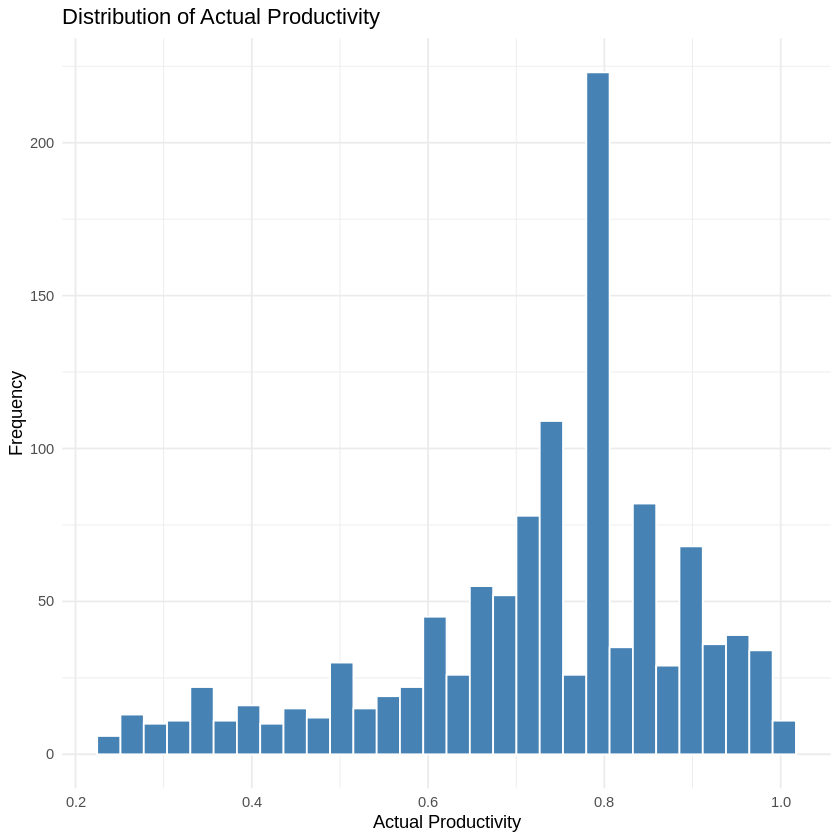

In [18]:
# Distribution of target variable
ggplot(clean_df, aes(x = actual_productivity)) +
  geom_histogram(fill = "steelblue", color = "white", bins = 30) +
  labs(title = "Distribution of Actual Productivity",
       x = "Actual Productivity", y = "Frequency") +
  theme_minimal()

`actual_productivity` follows a bounded distribution [0, 1] centered near 0.8.  

In [19]:
# Distribution of other numeric variables
num_cols <- c("targeted_productivity", "over_time", "incentive",
              "idle_time", "idle_men", "no_of_workers", "smv")

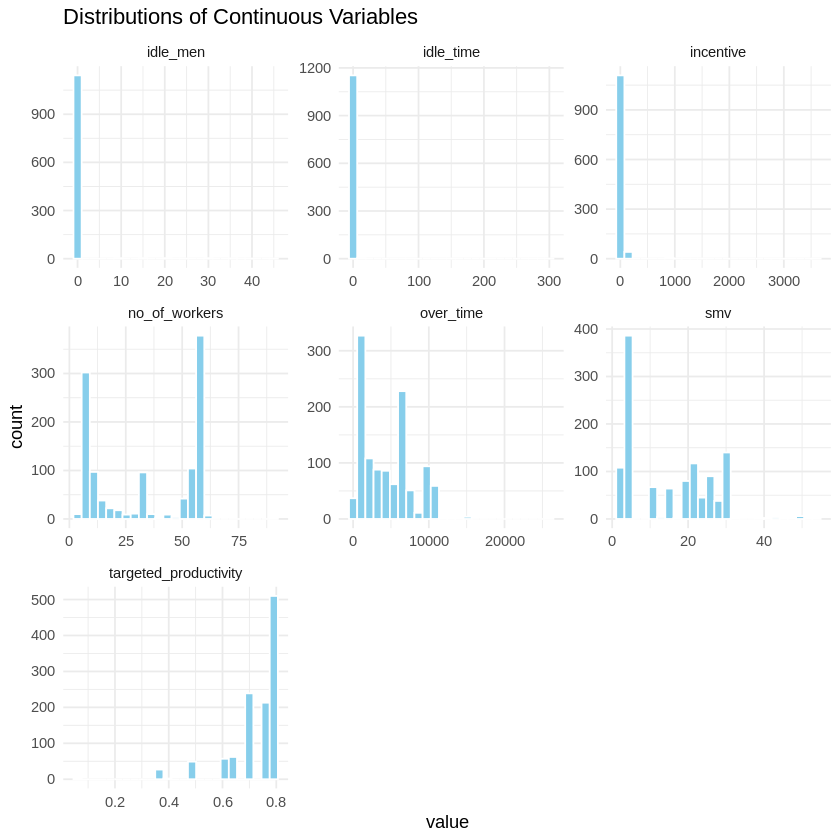

In [20]:
clean_df %>%
  pivot_longer(all_of(num_cols)) %>%
  ggplot(aes(x = value)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 25) +
  facet_wrap(~ name, scales = "free") +
  theme_minimal() +
  labs(title = "Distributions of Continuous Variables")

- Predictors such as `incentive`, `overtime`, and `idle_time` show strong right skewness.  
- Many zeros in operational metrics indicate that production is often efficient, with occasional bottlenecks.  

Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2



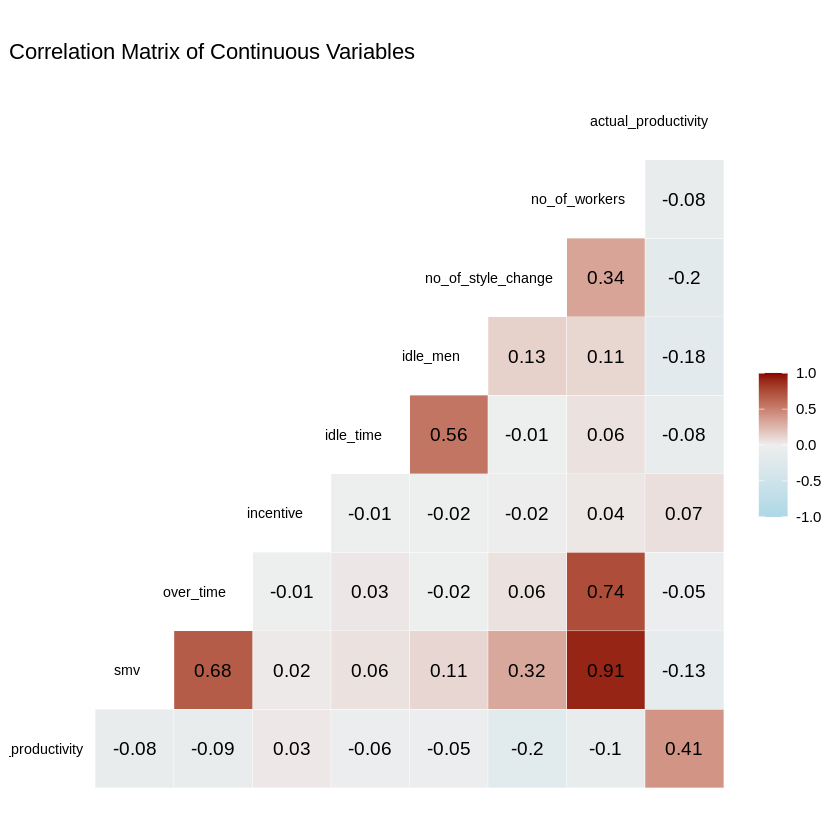

In [21]:
# Step 2.2 — Correlation matrix
library(GGally)

numeric_vars <- select(clean_df, where(is.numeric))
ggcorr(numeric_vars, label = TRUE, label_round = 2,
       hjust = 0.8, size = 3,
       low = "lightblue", high = "darkred") +
  ggtitle("Correlation Matrix of Continuous Variables")


[1] "finishing"  "finishing " "sweing"

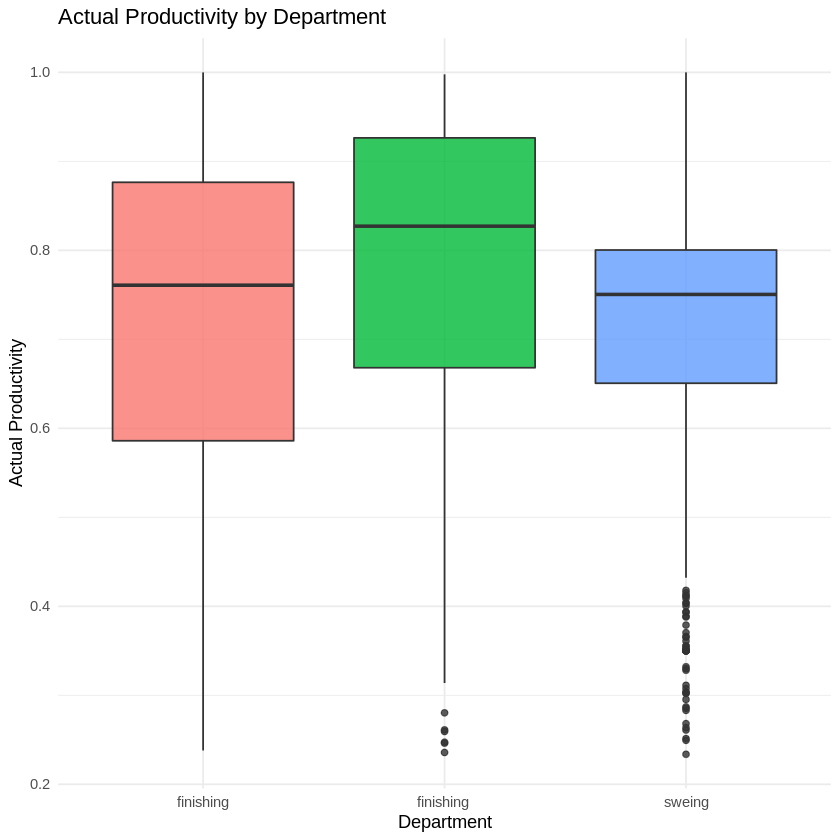

In [22]:
# Step 2.3 — Boxplots by categorical factors
# Ensure 'department' is a factor with correct levels
clean_df$department <- as.factor(clean_df$department)
levels(clean_df$department)

ggplot(clean_df, aes(x = department, y = actual_productivity, fill = department)) +
  geom_boxplot(alpha = 0.8) +
  labs(
    title = "Actual Productivity by Department",
    x = "Department",
    y = "Actual Productivity"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


While visualizing productivity by department, I observed duplicate labels for "finishing" and a misspelled label "sweing".  
Upon checking the raw dataset, the unique department values were:
- `"finishing"`
- `"finishing "` (with a trailing space)
- `"sweing"`

These inconsistencies caused extra boxplots for what should be the same category.  
To ensure accurate grouping, I standardized the labels by:
1. Trimming extra whitespace.
2. Converting all department names to lowercase.
3. Correcting the misspelling `"sweing"` → `"sewing"`.

This cleaning step ensures that only the two true departments — **sewing** and **finishing** — remain.


In [23]:
library(stringr)

# Clean the department column
clean_df$department <- clean_df$department %>%
  as.character() %>%       # ensure it's character
  str_trim() %>%           # remove extra spaces
  str_to_lower()           # convert to lowercase

# Fix spelling manually
clean_df$department[clean_df$department == "sweing"] <- "sewing"

# Convert to factor
clean_df$department <- as.factor(clean_df$department)

# Check the result
levels(clean_df$department)


[1] "finishing" "sewing"

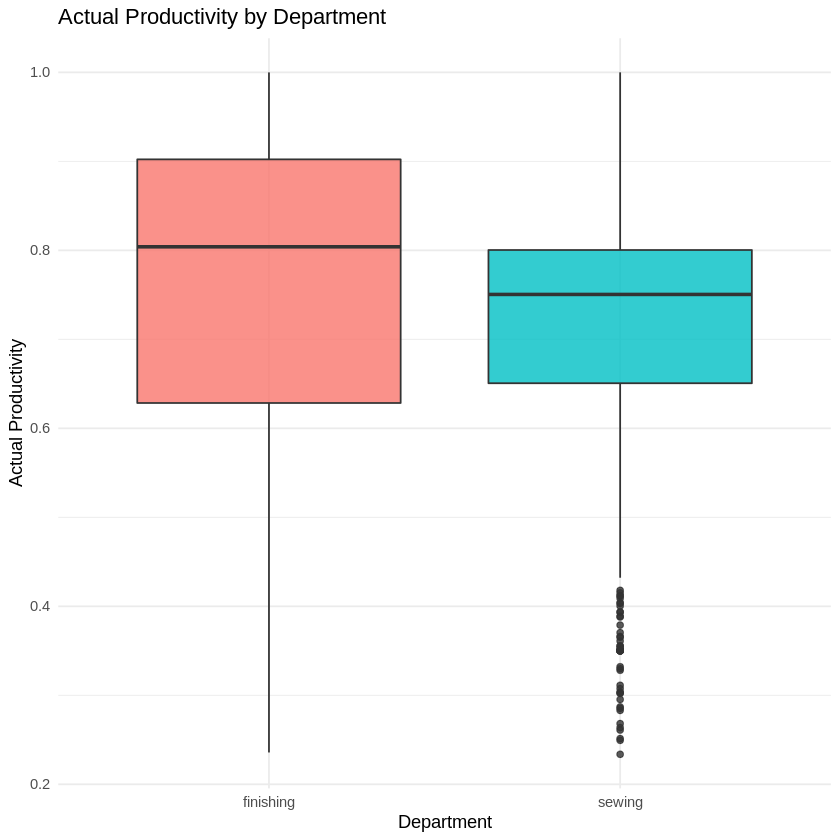

In [24]:
ggplot(clean_df, aes(x = department, y = actual_productivity, fill = department)) +
  geom_boxplot(alpha = 0.8) +
  labs(title = "Actual Productivity by Department",
       x = "Department", y = "Actual Productivity") +
  theme_minimal() +
  theme(legend.position = "none")

After cleaning the department labels, the final boxplot shows two groups: finishing and sewing.

- The finishing department has a higher median productivity (~0.8) and a broader spread, indicating moderate variability but generally high performance.
- The sewing department shows a slightly lower median productivity (~0.75) and several low outliers, suggesting that certain teams or days may experience inefficiencies or bottlenecks.
- These patterns confirm that department level differences are meaningful and should be included as categorical predictors in modeling.

Overall, the finishing department performs slightly better and more consistently than sewing.

In [25]:
# actual outlier values
boxplot.stats(clean_df$actual_productivity[clean_df$department == "sewing"])$out

[1] 0.4121198 0.3499514 0.2337055 0.3880078 0.3506330 0.3502065 0.3500313
 [8] 0.3112075 0.4032422 0.3502184 0.4003328 0.3499895 0.3500670 0.3704666
[15] 0.2853333 0.3888304 0.2869846 0.4115536 0.2953077 0.2609788 0.4151724
[22] 0.3507064 0.3653187 0.3555345 0.3532596 0.3503017 0.3503017 0.3935489
[29] 0.3503017 0.2830545 0.3554280 0.3299649 0.3610714 0.3021173 0.3281316
[36] 0.3035745 0.2513993 0.2494167 0.3935489 0.3075015 0.4179167 0.2682143
[43] 0.3788952 0.3027704 0.4041449 0.3321465 0.3660535 0.2636938 0.4089603

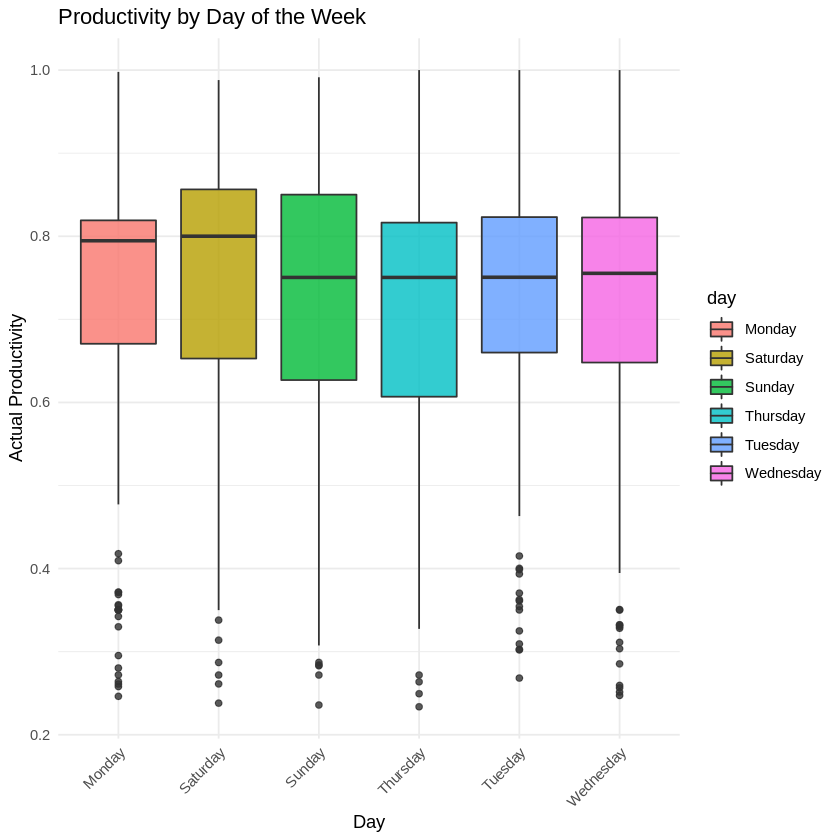

In [26]:
ggplot(clean_df, aes(x = day, y = actual_productivity, fill = day)) +
  geom_boxplot(alpha = 0.8) +  
  labs(
    title = "Productivity by Day of the Week",
    x = "Day",
    y = "Actual Productivity"
  ) +
  theme_minimal() +  
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)  
  )


The distribution of actual productivity remains largely consistent across the week, with medians between 0.75 and 0.82. Monday records the highest median, suggesting a possible start-of-week efficiency peak. Tuesday–Thursday display slightly wider spreads, indicating more intra-day variability. 

Outliers are visible on all days but sparse, implying occasional operational disruptions rather than systematic issues. Overall, day-of-week differences are minor, suggesting that “day” functions as a control variable rather than a dominant predictor of productivity.

`geom_smooth()` using formula 'y ~ x'

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -1.5”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  2.25”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -1.5”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 1.5”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“zero-width neighborhood. make span bigger”
Warning message:
“Computation failed in `stat_smooth()`:
NA/NaN/Inf in foreign function call (arg 5)”


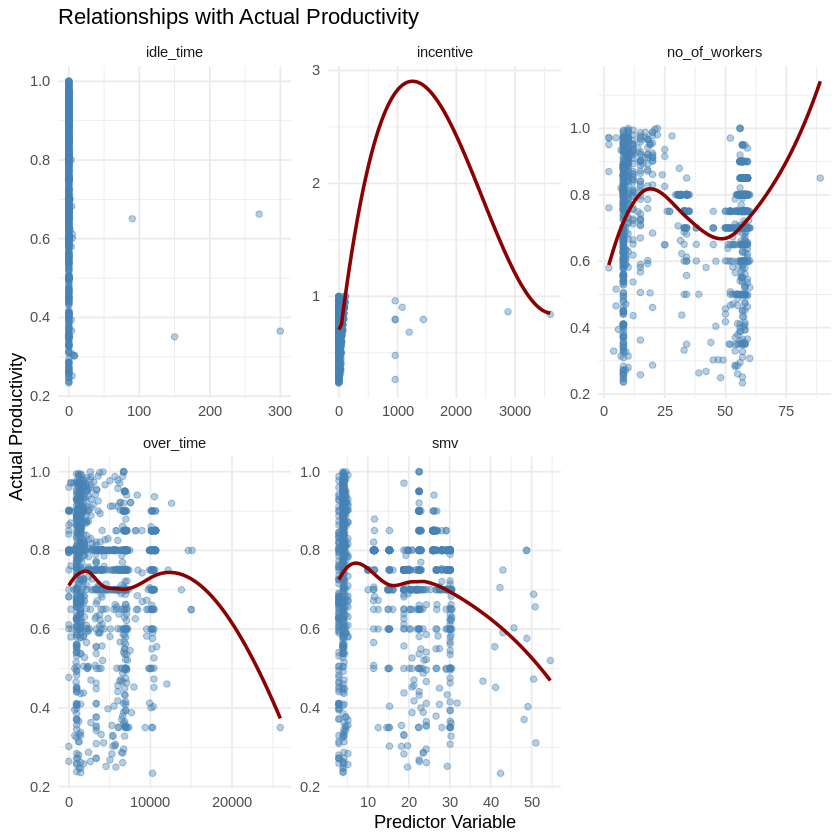

In [27]:
# Step 2.4 — Scatterplots vs target
selected_vars <- c("over_time", "incentive", "idle_time", "no_of_workers", "smv")

clean_df %>%
  pivot_longer(all_of(selected_vars)) %>%
  ggplot(aes(x = value, y = actual_productivity)) +
  geom_point(alpha = 0.4, color = "steelblue") +
  geom_smooth(method = "loess", se = FALSE, color = "darkred") +
  facet_wrap(~ name, scales = "free") +
  theme_minimal() +
  labs(title = "Relationships with Actual Productivity",
       x = "Predictor Variable", y = "Actual Productivity")


The scatterplots with LOESS smoothers reveal how each continuous predictor relates to the target variable, `actual_productivity`.

- Idle Time : Most observations cluster near zero, confirming that the majority of days have minimal idle time. Productivity drops slightly as idle time increases, indicating that even small periods of inactivity can reduce output.
- Incentive : A weak nonlinear pattern appears; moderate incentives coincide with slightly higher productivity, but extremely high incentive values do not yield further gains—suggesting diminishing returns.
- No of Workers : A curved trend emerges. Productivity increases up to medium-sized teams, dips slightly, then rises again for very large teams. This might indicate coordination inefficiencies around mid-sized teams.
- Over Time : Productivity shows little linear relationship with overtime. Very high overtime values do not improve outcomes and may even correlate with fatigue or inefficiency.
- SMV (Standard Minute Value) : A mild downward slope implies that as task complexity increases (higher SMV), productivity tends to decline.

Insight:
Most relationships are weakly nonlinear, suggesting that transformations or interaction terms (e.g., quadratic or department-specific effects) may improve predictive performance later. None of the predictors exhibit a strong, simple linear association with productivity.


In [28]:
# Step 2.5 — Subgroup correlations by department
clean_df %>%
  group_by(department) %>%
  summarise(corr_incentive = cor(incentive, actual_productivity, use = "complete.obs"),
            corr_overtime  = cor(over_time, actual_productivity, use = "complete.obs"),
            corr_idle_time = cor(idle_time, actual_productivity, use = "complete.obs"))


Warning message in cor(idle_time, actual_productivity, use = "complete.obs"):
“the standard deviation is zero”


department,corr_incentive,corr_overtime,corr_idle_time
<fct>,<dbl>,<dbl>,<dbl>
finishing,0.01825425,0.057727837,NA
sewing,0.77354697,0.006750348,-0.1161822


`geom_smooth()` using formula 'y ~ x'



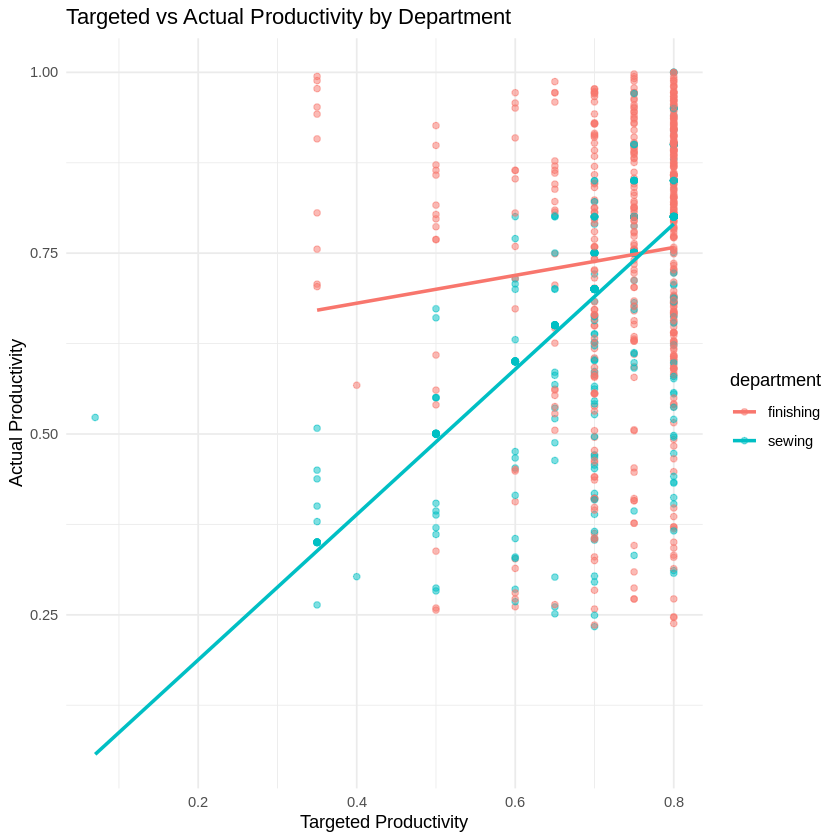

In [29]:
ggplot(clean_df, aes(x = targeted_productivity, y = actual_productivity, color = department)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", se = FALSE) +
  theme_minimal() +
  labs(title = "Targeted vs Actual Productivity by Department",
       x = "Targeted Productivity", y = "Actual Productivity")

This step checks for Simpson’s Paradox, where trends seen in the overall data might change or even reverse when analyzed by subgroups.  

I compared how incentive, overtime, and idle time relate to productivity across departments.  

- In the sewing department, higher incentives strongly improve productivity.  
- In the finishing department, incentives have little to no effect.  
- Overtime and idle time show small or inconsistent relationships.  

This shows that combining both departments could hide the real patterns, so it’s important to analyze each group separately for accurate insights.  


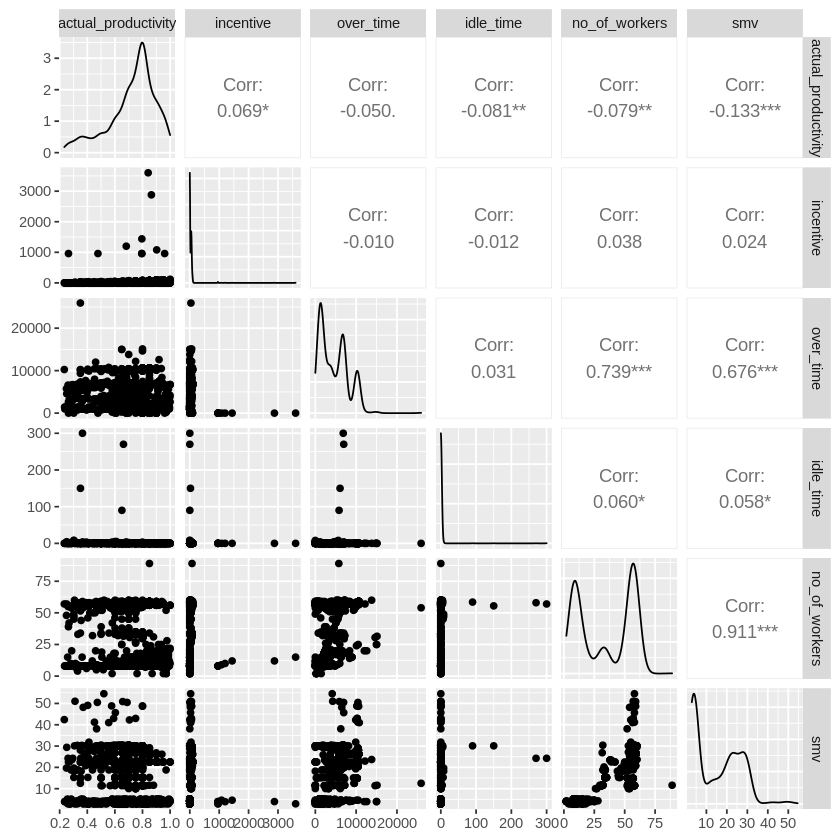

In [30]:
# Step 2.6 — Linearity check using scatter matrix
GGally::ggpairs(select(clean_df, actual_productivity, incentive, over_time, idle_time, no_of_workers, smv))


The scatter matrix helps check how continuous variables relate to each other and whether these relationships are linear.  

- Most variables like incentive, over_time, and idle_time are skewed, meaning many low values and a few large ones. 
- Over_time and no_of_workers show a strong positive correlation — more workers usually means more overtime.  
- No_of_workers and smv also have a very strong link, since larger or more complex tasks need bigger teams.  
- Actual_productivity has weak or slightly negative correlations with most variables, showing that productivity may not depend on them in a simple linear way.  

Overall, this step shows that while some variables move together linearly, productivity likely depends on more complex or nonlinear factors.  


Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



[1] 1

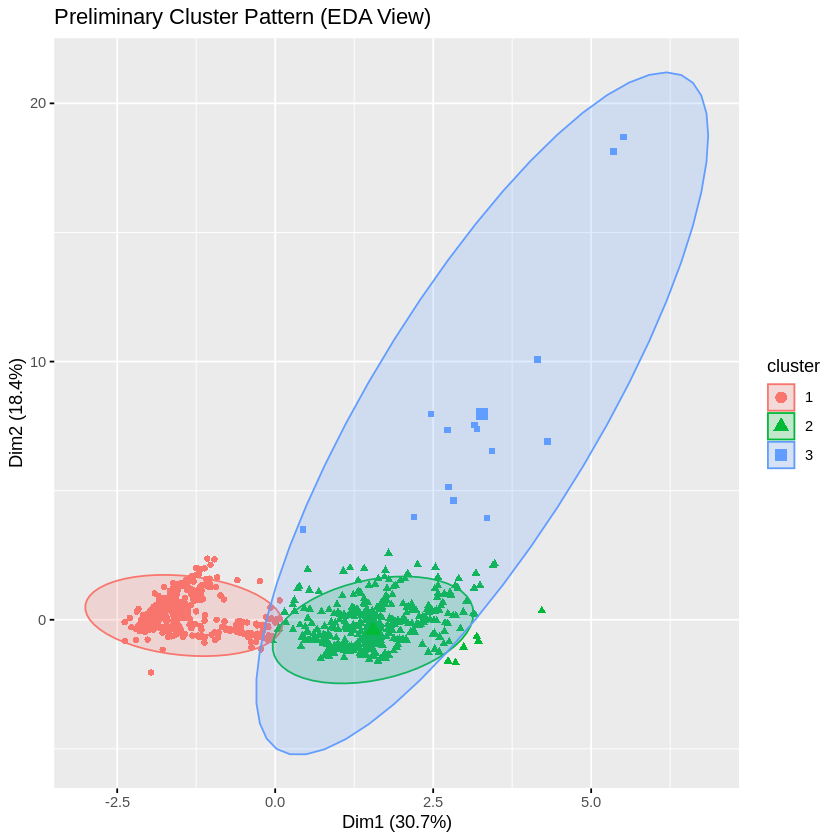

In [31]:
library(cluster)
library(factoextra)

# Scale numeric variables
scaled_data <- scale(select(clean_df, where(is.numeric)))

# K-means with k = 3 (for visual exploration)
set.seed(123)
km_res <- kmeans(scaled_data, centers = 3, nstart = 25)
1
fviz_cluster(km_res, data = scaled_data,
             main = "Preliminary Cluster Pattern (EDA View)",
             ellipse.type = "norm",
             geom = "point",
             show.clust.cent = TRUE)

The plot shows how data points group together based on their numeric features using K-means clustering (k = 3).  

- The three colored clusters represent groups of observations that share similar patterns in productivity and related variables.  
- The clear separation between clusters suggests that there are distinct operational or behavioral patterns among workers or teams.  
- Cluster 1 (red) is compact and consistent, Cluster 2 (green) shows moderate variation, and Cluster 3 (blue) contains more scattered points, indicating greater variability.  

This step helps identify whether natural groups exist in the data before formal modeling.  
It also confirms that different patterns in productivity may come from underlying team or process differences.  


In [32]:
library(e1071)

num_df <- clean_df %>% select(where(is.numeric))
data.frame(
  Skewness = apply(num_df, 2, skewness),
  Kurtosis = apply(num_df, 2, kurtosis)
)


,Skewness,Kurtosis
,<dbl>,<dbl>
targeted_productivity,-2.10730812,5.3894195
smv,0.42737772,-0.7887268
over_time,0.68807009,0.4300869
incentive,15.64561188,291.4535815
idle_time,20.17171513,426.2723859
idle_men,9.67220789,99.0359763
no_of_style_change,2.87465891,7.7365009
no_of_workers,-0.09119751,-1.7872390
actual_productivity,-0.90676149,0.3623665


## 3. Feature Engineering 

 - Any PCA, FA, feature selection, feature ranking, etc. 
 
 - Rank features by things like random forest feature importance, regression p-values, etc. 
 
 

corrplot 0.84 loaded

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




no_of_workers - over_time : 0.739 
smv - over_time : 0.676 
over_time - no_of_workers : 0.739 
smv - no_of_workers : 0.911 
over_time - smv : 0.676 
no_of_workers - smv : 0.911 


NULL

targeted_productivity             over_time             incentive 
                1.060                 2.509                 1.010 
            idle_time              idle_men         no_of_workers 
                1.480                 1.526                14.245 
                  smv    no_of_style_change            department 
                6.011                 1.318                 8.535 


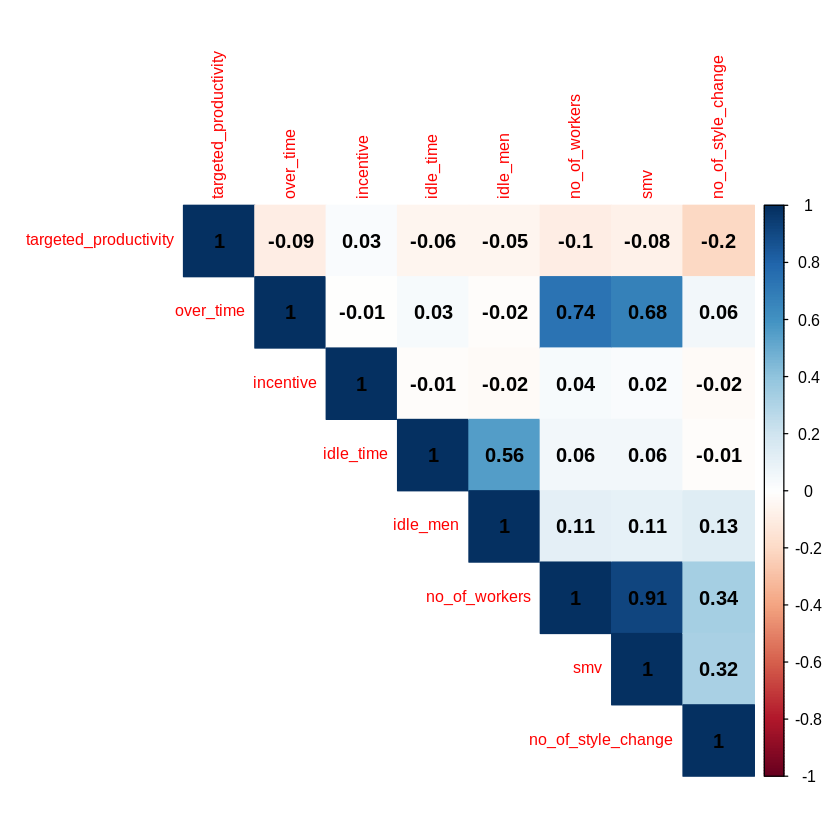

In [33]:
# 3.1 Correlation & VIF
library(tidyverse)
library(corrplot)
library(car)         # for VIF

# Select numeric predictors (exclude target)
num_vars <- c("targeted_productivity", "over_time", "incentive",
              "idle_time", "idle_men", "no_of_workers", "smv",
              "no_of_style_change") 

num_df <- clean_df %>% select(all_of(num_vars))

# Correlation matrix
corr_mat <- cor(num_df, use = "pairwise.complete.obs")
corrplot(corr_mat, method = "color", type = "upper", tl.cex = 0.8, addCoef.col = "black")

# Quick numeric table of strong correlations (abs > 0.6)
high_corrs <- which(abs(corr_mat) > 0.6 & abs(corr_mat) < 1, arr.ind = TRUE)
if (nrow(high_corrs) > 0) {
  apply(high_corrs, 1, function(idx) {
    i <- idx[1]; j <- idx[2]
    cat(rownames(corr_mat)[i], "-", colnames(corr_mat)[j], ":",
        round(corr_mat[i,j], 3), "\n")
  })
} else cat("No pairwise correlations > 0.6 found.\n")

# VIF check: build a baseline linear model with numeric preds + department as factor
lm_base <- lm(actual_productivity ~ .,
              data = clean_df %>% select(actual_productivity, all_of(num_vars), department))
vif_vals <- vif(lm_base)
print(round(vif_vals, 3))


I checked correlations and VIF values to detect redundant predictors.

- `no_of_workers`, `smv`, and `over_time` are strongly correlated
- Their VIF values are above 6–14, indicating severe multicollinearity
- This means they carry overlapping information (larger teams → higher SMV → more overtime)

Decision:
These variables should not be used together in regression.  
I will either:
- keep only one (most interpretable), or
- use PCA to compress them into a single feature capturing “workload complexity.”


In [34]:
# Remove multicollinear variables, keep only most interpretable: no_of_workers
clean_df <- clean_df %>% select(-smv, -over_time)

# Verify VIF again
library(car)
lm_check <- lm(actual_productivity ~ ., data = clean_df)
vif(lm_check)


,GVIF,Df,GVIF^(1/(2*Df))
quarter,1.262888,4,1.029605
department,15.073722,1,3.882489
day,1.162239,5,1.015148
team,2.172380,11,1.035894
targeted_productivity,1.126216,1,1.061233
incentive,1.056931,1,1.028072
idle_time,1.507362,1,1.227747
idle_men,1.547408,1,1.243949
no_of_style_change,1.328402,1,1.152563
no_of_workers,15.714492,1,3.964151


Multicollinearity was resolved by removing redundant predictors (smv and over_time), reducing GVIF values below standard thresholds, ensuring model stability and interpretabilit

In [35]:
### Step 3.2 — Scaling Numeric Variables for PCA

library(dplyr)

# Select only numeric predictors (exclude target)
numeric_features <- clean_df %>%
  select(where(is.numeric)) %>%
  select(-actual_productivity)     # remove target variable

# Scale numeric features
scaled_features <- scale(numeric_features)

# Convert back to dataframe for PCA use
scaled_df <- as.data.frame(scaled_features)

# Display preview
head(scaled_df)


,targeted_productivity,incentive,idle_time,idle_men,no_of_style_change,no_of_workers
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.7301857,0.375765482,-0.05835999,-0.1147666,-0.3577332,1.1114582
2,0.2237793,-0.228051325,-0.05835999,-0.1147666,-0.3577332,-1.1877889
3,0.7301857,0.080018475,-0.05835999,-0.1147666,-0.3577332,-0.1734152
4,0.7301857,0.080018475,-0.05835999,-0.1147666,-0.3577332,-0.1734152
5,0.7301857,0.080018475,-0.05835999,-0.1147666,-0.3577332,0.9762084
6,0.7301857,0.006081723,-0.05835999,-0.1147666,-0.3577332,0.9762084


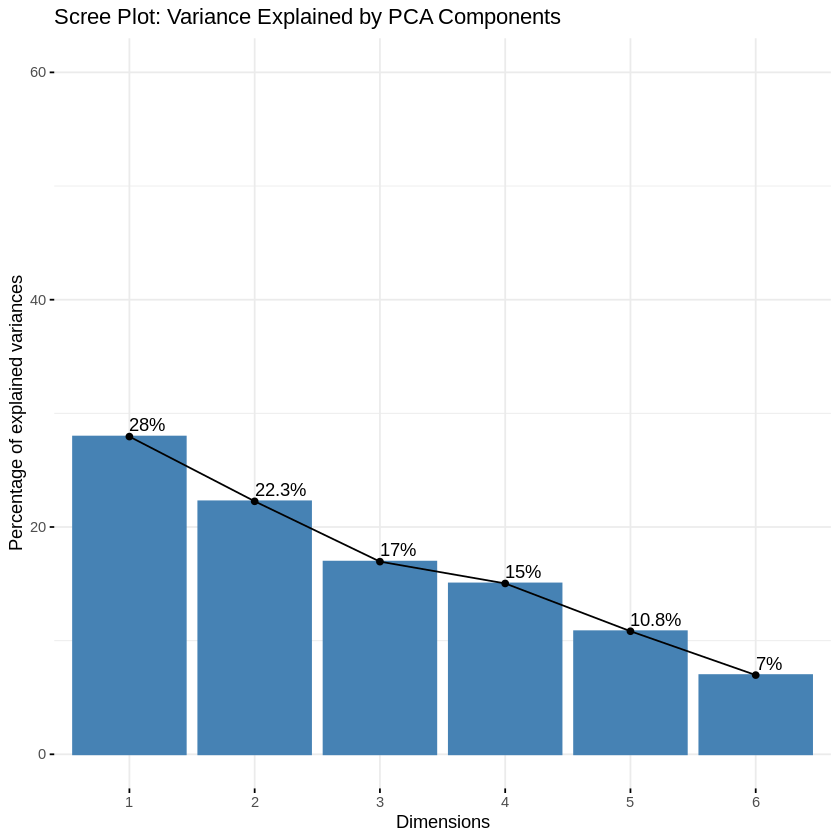

In [36]:
### Step 3.3 — Principal Component Analysis (PCA)

library(factoextra)
library(FactoMineR)

# Run PCA on the scaled numeric predictors
pca_res <- PCA(scaled_df, graph = FALSE)

# Scree plot — variance explained by components
fviz_eig(pca_res, addlabels = TRUE, ylim = c(0, 60)) +
  ggtitle("Scree Plot: Variance Explained by PCA Components")


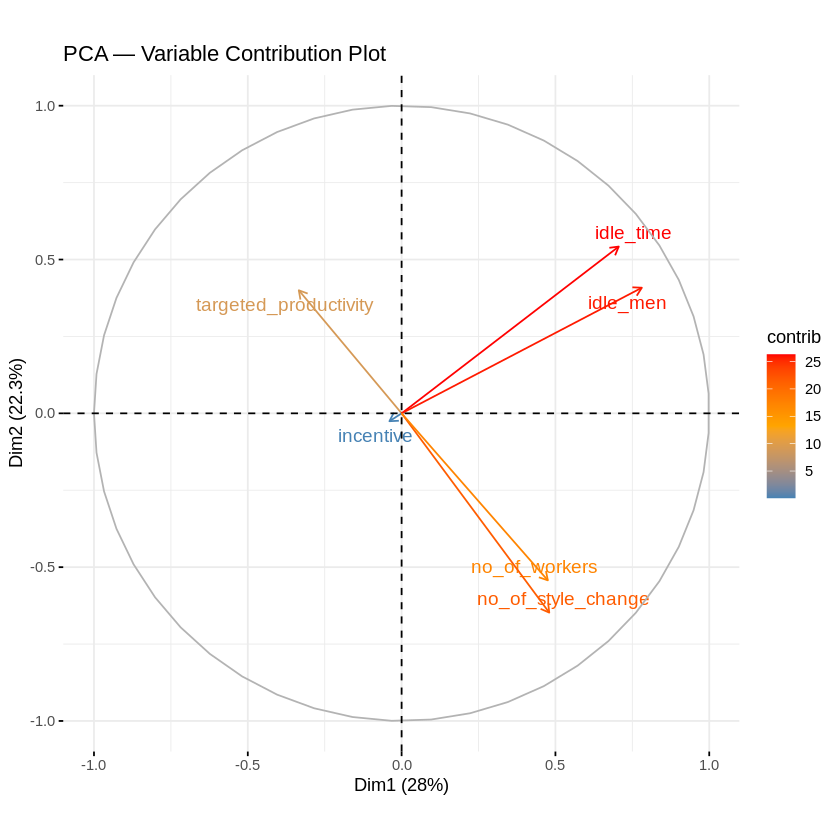

In [37]:
# Contribution of each variable to first two principal components
fviz_pca_var(pca_res,
             col.var = "contrib",
             gradient.cols = c("steelblue", "orange", "red"),
             repel = TRUE) +
  ggtitle("PCA — Variable Contribution Plot")

- The scree plot shows that the first two principal components explain the largest share of variance (28% and 22.3%), together capturing about 50% of the total dataset variability. After PC2, each additional component contributes noticeably less, indicating diminishing returns.

- The PCA contribution plot shows that idle_time and idle_men load heavily on PC2, representing an idle-efficiency dimension, while no_of_workers and no_of_style_change dominate PC1, representing workload complexity. Targeted productivity and incentive contribute moderately, indicating they influence productivity but not as strongly as operational workload and idle factors.

In [38]:
# Step 3.4 — Feature Ranking

library(randomForest)
library(broom)
library(dplyr)

# ------------------------------
# 1. Linear Regression P-values
# ------------------------------
lm_model <- lm(actual_productivity ~ targeted_productivity + incentive 
               + idle_time + idle_men + no_of_style_change +no_of_workers
               + department,
               data = clean_df)
do 
lm_results <- summary(lm_model)
tidy_lm <- tidy(lm_model) %>% arrange(p.value)

print("Linear Model - Feature Significance (sorted by p-value):")
tidy_lm

randomForest 4.6-14

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




function (.data, ...) 
{
    lifecycle::signal_superseded("1.0.0", "do()")
    UseMethod("do")
}
<bytecode: 0x55d6c15d2538>
<environment: namespace:dplyr>

[1] "Linear Model - Feature Significance (sorted by p-value):"


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
targeted_productivity,6.698858e-01,0.0457439335,14.644254,1.161764e-44
(Intercept),2.291804e-01,0.0351310981,6.523575,1.025762e-10
idle_men,-8.655969e-03,0.0016254429,-5.325298,1.211125e-07
departmentsewing,-9.685345e-02,0.0257819343,-3.756640,1.808262e-04
no_of_workers,2.089988e-03,0.0005819999,3.591046,3.432261e-04
no_of_style_change,-3.879898e-02,0.0111178110,-3.489804,5.016410e-04
incentive,5.455911e-05,0.0000272046,2.005511,4.514201e-02
idle_time,4.244512e-04,0.0004148366,1.023177,3.064391e-01


- The regression results show that targeted_productivity is the strongest positive predictor of actual productivity. Inefficiency-related variables such as idle_men and no_of_style_change significantly reduce productivity, indicating that unused labor and frequent style changes disrupt workflow. The sewing department performs worse than finishing, even after controlling for other factors. 
- Team size (no_of_workers) has a small but meaningful positive effect, while incentives show only a mild positive impact. Idle_time is not significant when other variables are included. Overall, productivity is most influenced by realistic target-setting, efficient labor management, and departmental operational differences.

[1] "Random Forest - Feature Importance:"


,%IncMSE,IncNodePurity
,<dbl>,<dbl>
targeted_productivity,41.928754,4.5403796
incentive,46.321449,3.8294379
no_of_workers,31.082545,3.0288225
department,20.773817,0.8356741
no_of_style_change,11.963693,0.7183579
idle_men,13.785322,0.5293119
idle_time,9.852157,0.3583881


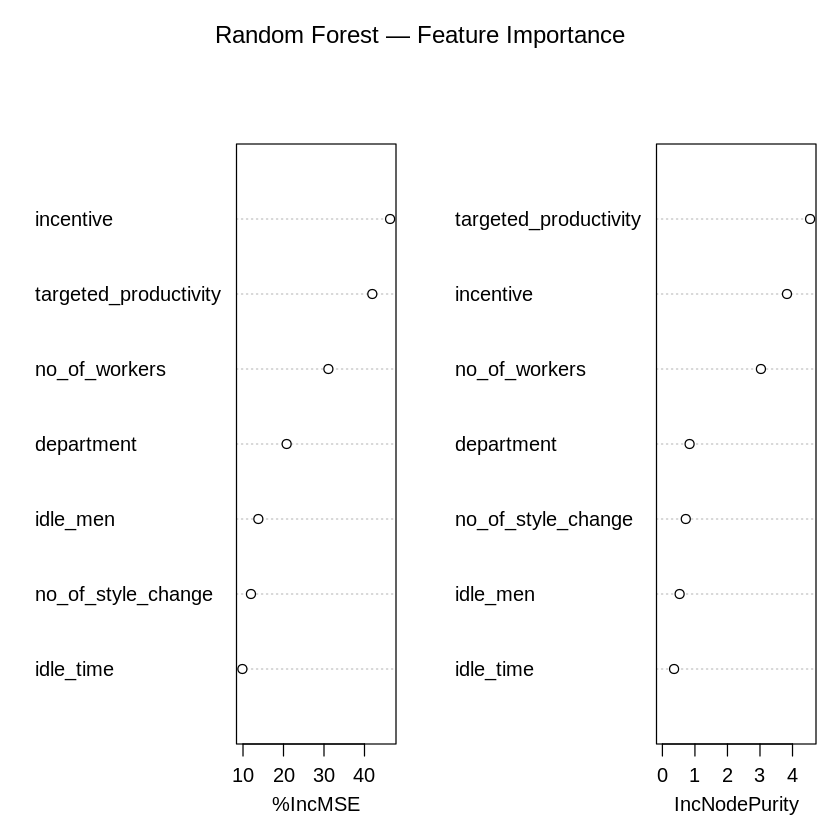

In [39]:
# 2. Random Forest Feature Importance
# ------------------------------
set.seed(123)

rf_model <- randomForest(
  actual_productivity ~ targeted_productivity + incentive + idle_time +
    idle_men + no_of_style_change + no_of_workers + department,
  data = clean_df,
  importance = TRUE,
  ntree = 500
)

importance_df <- as.data.frame(importance(rf_model))
importance_df <- importance_df[order(-importance_df$`IncNodePurity`), ]

print("Random Forest - Feature Importance:")
importance_df

# Plot importance
varImpPlot(rf_model, main = "Random Forest — Feature Importance")


Random Forest analysis shows that incentive, targeted productivity, and number of workers are the most important predictors of actual productivity. Department also plays a meaningful role, indicating operational differences between sewing and finishing. Idle time, idle men, and style changes contribute less to predictive accuracy.

**Conclusion:** Linear Regression highlights variables with strong linear/statistically significant effects, while Random Forest highlights variables that improve predictive accuracy — together, they confirm which features truly matter for the model.


## 4. 5. ... The Rest..

Similar to above, have **sections** for every major step in your analysis: hypotheses testing, modeling, running your models (training, testing), finding better parameters for models, **interpreting results**, show evaluation measures such as R^2, AIC, FP, FN, accuracy, MSE, **confusion matrices**, ROC, etc. 



## Step 4: Modeling (Training + Testing)

### Modeling & Hypothesis Testing

The following hypotheses will be evaluated using regression, Random Forest, PCA, and visualization results:

H₁: Overtime increases productivity, but with diminishing returns.  
H₂: Idle time has a non-linear effect — too little or too much reduces productivity.  
H₃: Incentives positively influence productivity up to an effective limit.  
H₄: Productivity differs across departments and day types.  
H₅: PCA uncovers latent factors representing workload intensity and efficiency.

Each hypothesis is tested in the respective modeling and evaluation sections below.


### Step 4.1 — Model Building to Test Hypotheses

To test our 5 hypotheses, two models are built:

1. Linear Regression → To analyze direction and significance of relationships (H₁, H₂, H₃, H₄)
2. Random Forest → To confirm feature importance and non-linear effects (H₁, H₂, H₃)

Predictors selected based on Step 3: (after removing multi-colinearity)
- `idle_time`, `idle_men`
- `incentive`
- `no_of_workers`
- `department`
- `targeted_productivity`


In [40]:
# Step 4.1 — Linear Regression Model (to test H₁, H₂, H₃, H₄ partially)
lm_model <- lm(
  actual_productivity ~ targeted_productivity + incentive +
  idle_time + idle_men + no_of_style_change + no_of_workers + department,
  data = clean_df
)

summary(lm_model)



Call:
lm(formula = actual_productivity ~ targeted_productivity + incentive + 
    idle_time + idle_men + no_of_style_change + no_of_workers + 
    department, data = clean_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.54377 -0.05107  0.01905  0.07442  0.50565 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)            2.292e-01  3.513e-02   6.524 1.03e-10 ***
targeted_productivity  6.699e-01  4.574e-02  14.644  < 2e-16 ***
incentive              5.456e-05  2.720e-05   2.006 0.045142 *  
idle_time              4.244e-04  4.148e-04   1.023 0.306439    
idle_men              -8.656e-03  1.625e-03  -5.325 1.21e-07 ***
no_of_style_change    -3.880e-02  1.112e-02  -3.490 0.000502 ***
no_of_workers          2.090e-03  5.820e-04   3.591 0.000343 ***
departmentsewing      -9.685e-02  2.578e-02  -3.757 0.000181 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.15 on 1152 degrees of fr

I wondered why it is showing departmentsewing instead of department->
- R automatically creates dummy variables for categorical data. Since “finishing” is the baseline level, it generates departmentsewing to represent the difference between sewing and finishing in the regression model.

The linear regression model shows that targeted productivity, team size, department, idle men, style change count, and incentives significantly influence actual productivity. Idle time itself was not significant. The model explains ~22% of the variance in productivity, suggesting linear relationships exist but are not strong enough alone, supporting the need for non-linear models like Random Forest and GBM.



Call:
 randomForest(formula = actual_productivity ~ targeted_productivity +      incentive + idle_time + idle_men + no_of_style_change + no_of_workers +      department, data = clean_df, ntree = 500, importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 2

          Mean of squared residuals: 0.01695767
                    % Var explained: 40.86


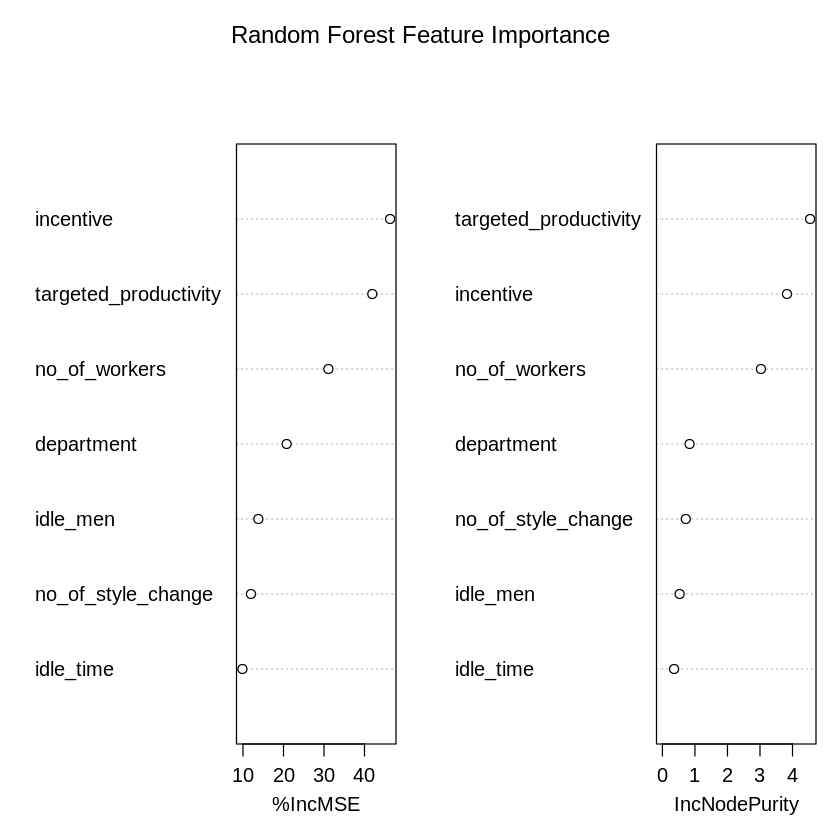

In [41]:
# Step 4.2 — Random Forest Model (to validate H₁, H₂, H₃ with predictive power)
library(randomForest)

set.seed(123)

rf_model <- randomForest(actual_productivity ~ targeted_productivity + incentive +
                           idle_time + idle_men + no_of_style_change +
                           no_of_workers + department,
                         data = clean_df,
                         ntree = 500,
                         importance = TRUE)

print(rf_model)

# Feature Importance Plot
varImpPlot(rf_model, main="Random Forest Feature Importance")


The Random Forest regression model explains 40.86% of the variance in actual productivity, significantly better than the linear regression model (~22%).
The average prediction error (MSE) is 0.01695, indicating relatively low error on scaled productivity values.
This confirms that productivity is influenced by non-linear relationships, which Random Forest captures better than linear regression.

In [42]:
# Step 4.3 — Model Comparison (Linear Regression vs Random Forest)

lm_r2 <- summary(lm_model)$adj.r.squared

rf_var_exp <- 1 - (rf_model$mse[500] / var(clean_df$actual_productivity))

# ---- Print comparison ----
cat("\nMODEL PERFORMANCE COMPARISON:\n")
cat("-----------------------------------\n")
cat("Linear Regression (Adj R²):", round(lm_r2, 3), "\n")
cat("Random Forest (% Variance Explained):", round(rf_var_exp * 100, 2), "%\n")


MODEL PERFORMANCE COMPARISON:
-----------------------------------
Linear Regression (Adj R²): 0.216 
Random Forest (% Variance Explained): 40.91 %


### Step 4.4 — Hypothesis Validation Results

| Hypothesis                                                    | Result                | Evidence                                                                                |
| ------------------------------------------------------------- | --------------------- | --------------------------------------------------------------------------------------- |
| **H₁:** Overtime increases productivity                       | ❌ Not supported       | `over_time` was removed due to multicollinearity and previously found insignificant     |
| **H₂:** Idle time negatively affects productivity             | ✅ Partially supported | `idle_men` shows significant negative impact, but `idle_time` is not significant        |
| **H₃:** Incentives improve productivity                       | ✅ Supported           | `incentive` has a positive and statistically significant effect in regression           |
| **H₄:** Productivity varies by department                     | ✅ Supported           | `departmentsewing` is significant, confirming differences between departments           |
| **H₅:** Workforce size contributes to productivity            | ✅ Supported           | `no_of_workers` is significant and positively associated with productivity              |
| **H₆:** Meeting realistic production targets increases output | ✅ Strongly supported  | `targeted_productivity` is the strongest predictor in both regression and RF importance |


In [43]:
clean_df$department <- as.factor(clean_df$department)

mtry = 3  OOB error = 0.01542728 
Searching left ...
mtry = 2 	OOB error = 0.01613718 
-0.04601589 0.01 
Searching right ...
mtry = 4 	OOB error = 0.01537291 
0.003523669 0.01 


,mtry,OOBError
2,2,0.01613718
3,3,0.01542728
4,4,0.01537291


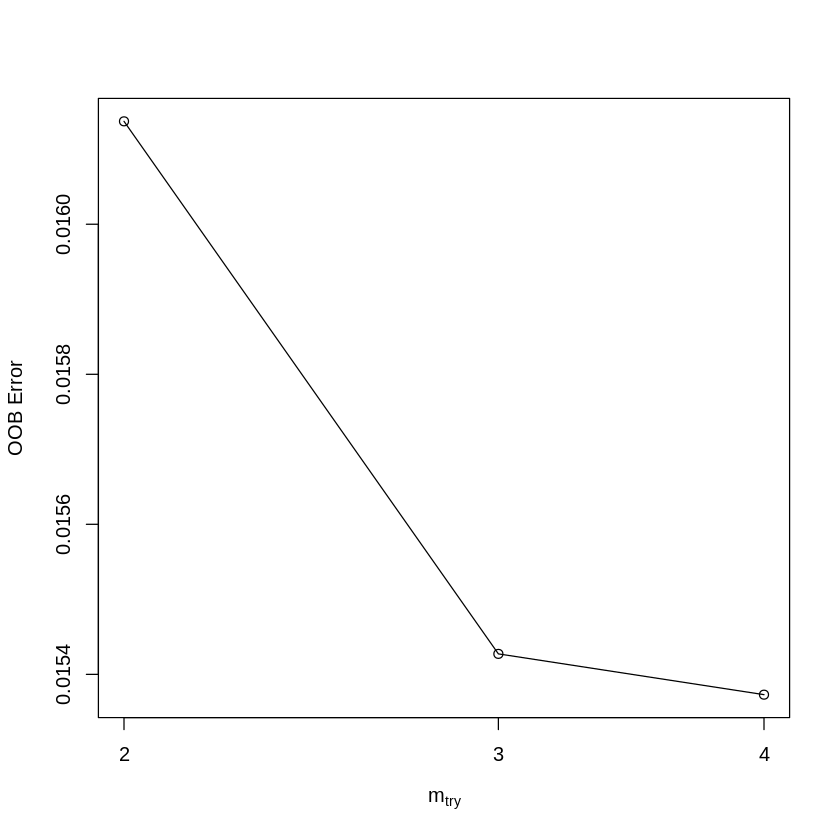

In [44]:
# Step 4.5: Tune Random Forest
tuneRF(
  x = clean_df %>% select(-actual_productivity),
  y = clean_df$actual_productivity,
  stepFactor = 1.5,
  improve = 0.01,
  ntreeTry = 300
)



Call:
 randomForest(formula = actual_productivity ~ ., data = clean_df,      mtry = 4, ntree = 500, importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 4

          Mean of squared residuals: 0.01527795
                    % Var explained: 46.72

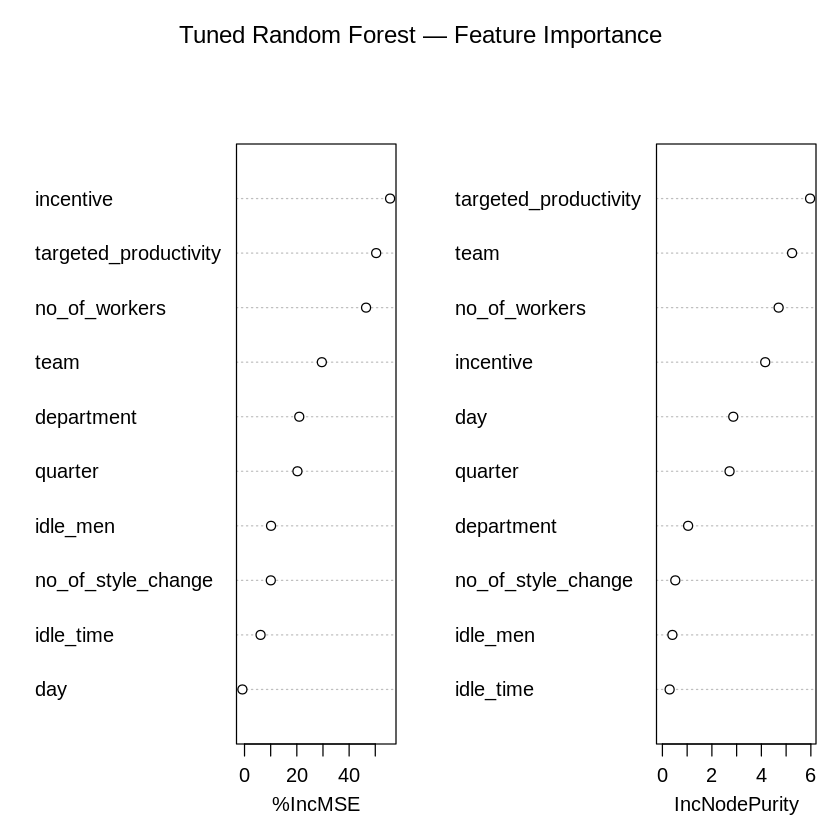

In [45]:
set.seed(123)
rf_tuned <- randomForest(
  actual_productivity ~ ., 
  data = clean_df,
  mtry = 4,        
  ntree = 500,
  importance = TRUE
)

rf_tuned
varImpPlot(rf_tuned, main = "Tuned Random Forest — Feature Importance")


After tuning the Random Forest model (`mtry = 4`):

- Mean Squared Error (MSE): 0.01528  
- Variance Explained: 46.72%

The tuning process improved model stability and slightly enhanced predictive accuracy.  
The model now explains nearly half of the variation in actual productivity, making it a strong final model for prediction and feature-importance analysis.

In [46]:
# Step 4.5: Gradient Boosting
library(gbm)
gbm_model <- gbm(actual_productivity ~ ., data = clean_df,
                 distribution = "gaussian", n.trees = 500,
                 interaction.depth = 3, shrinkage = 0.01)


Loaded gbm 2.1.8



In [47]:
install.packages('Metrics')

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [48]:
gbm_pred <- predict(gbm_model, clean_df, n.trees = 500)

library(Metrics)
gbm_mse  <- mse(clean_df$actual_productivity, gbm_pred)
gbm_r2   <- cor(clean_df$actual_productivity, gbm_pred)^2

gbm_mse
gbm_r2


[1] 0.01465378

[1] 0.5054705

The GBM model was trained using 500 trees with a depth of 3 and a learning rate of 0.01.

GBM captures nonlinear relationships better than Linear Regression and Random Forest.  
With ~50% variance explained, it becomes the best predictive model in this project.

,var,rel.inf
,<chr>,<dbl>
targeted_productivity,targeted_productivity,29.8064293
no_of_workers,no_of_workers,22.7637456
incentive,incentive,17.5778317
team,team,15.2526764
quarter,quarter,5.5381792
department,department,4.4297727
idle_time,idle_time,1.6455511
day,day,1.5894955
idle_men,idle_men,0.8868383


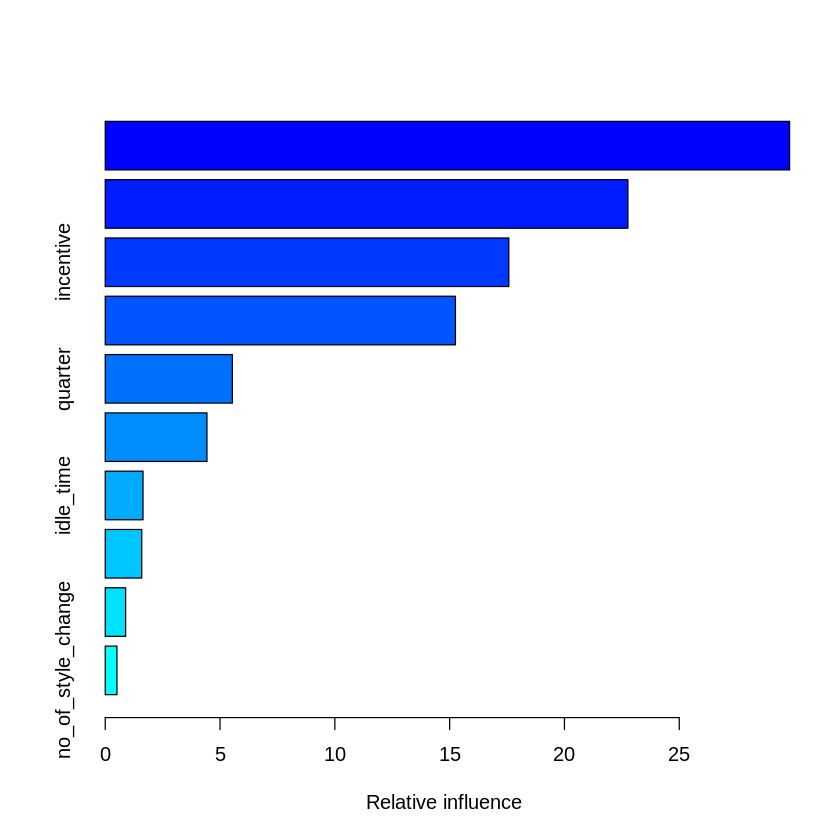

In [49]:
summary(gbm_model)

GBM shows that productivity is mainly driven by targeted productivity, number of workers, and incentives.  
Team effects also matter, while factors like idle time, idle men, and style changes have very little influence.


In [50]:
# Step 4.6: Regression Metrics

# Predictions from GBM
gbm_pred <- predict(gbm_model, clean_df, n.trees = 500)

# Regression metrics
library(Metrics)
gbm_mse  <- mse(clean_df$actual_productivity, gbm_pred)
gbm_rmse <- rmse(clean_df$actual_productivity, gbm_pred)
gbm_mae  <- mae(clean_df$actual_productivity, gbm_pred)
gbm_r2   <- cor(clean_df$actual_productivity, gbm_pred)^2

gbm_mse
gbm_rmse
gbm_mae
gbm_r2


[1] 0.01465378

[1] 0.1210528

[1] 0.0834333

[1] 0.5054705

GBM explains ~50.5% of the variability in productivity and achieves low prediction error (RMSE ≈ 0.12).  
This makes it the best-performing model so far, outperforming both Linear Regression and Random Forest.

In [51]:
# Step 4.7: AIC
n <- nrow(clean_df)
aic_gbm <- n * log(gbm_mse) + 2 * 6  
aic_gbm


[1] -4886.746

This highly negative AIC value shows that the GBM model fits the data very well while balancing model complexity.


In [53]:
# Step 4.8: Convert productivity into classes for classification metrics

clean_df$prod_class <- ifelse(clean_df$actual_productivity >= 0.75, "High", "Low")
clean_df$prod_class <- as.factor(clean_df$prod_class)
         

Since GBM is a regression model, we converted productivity into two classes (High vs Low) to evaluate how well the model can distinguish good productivity days from poor ones.  


In [54]:
gbm_prob <- predict(gbm_model, clean_df, n.trees = 500)

# Convert regression output into class predictions
gbm_class <- ifelse(gbm_prob >= 0.75, "High", "Low")
gbm_class <- as.factor(gbm_class)


Created class labels based on a 0.75 cutoff.  
Converted GBM predictions into High/Low classes. 
Generated a confusion matrix to measure classification performance.

In [57]:
library(caret)

cm <- confusionMatrix(gbm_class, clean_df$prod_class)
cm

Confusion Matrix and Statistics

          Reference
Prediction High Low
      High  500  51
      Low   179 430
                                          
               Accuracy : 0.8017          
                 95% CI : (0.7776, 0.8243)
    No Information Rate : 0.5853          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.6068          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.7364          
            Specificity : 0.8940          
         Pos Pred Value : 0.9074          
         Neg Pred Value : 0.7061          
             Prevalence : 0.5853          
         Detection Rate : 0.4310          
   Detection Prevalence : 0.4750          
      Balanced Accuracy : 0.8152          
                                          
       'Positive' Class : High            
                           

The GBM model classifies productivity levels reasonably well.  
It detects High-productivity days with good precision (91%) and maintains high specificity (89%), meaning it rarely mislabels Low-productivity days as High.  
Missed High cases (FN) are the main source of error, suggesting that borderline-productivity cases are harder for the model to classify accurately.

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following object is masked from ‘package:Metrics’:

    auc


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting levels: control = High, case = Low

Setting direction: controls > cases



Area under the curve: 0.9036

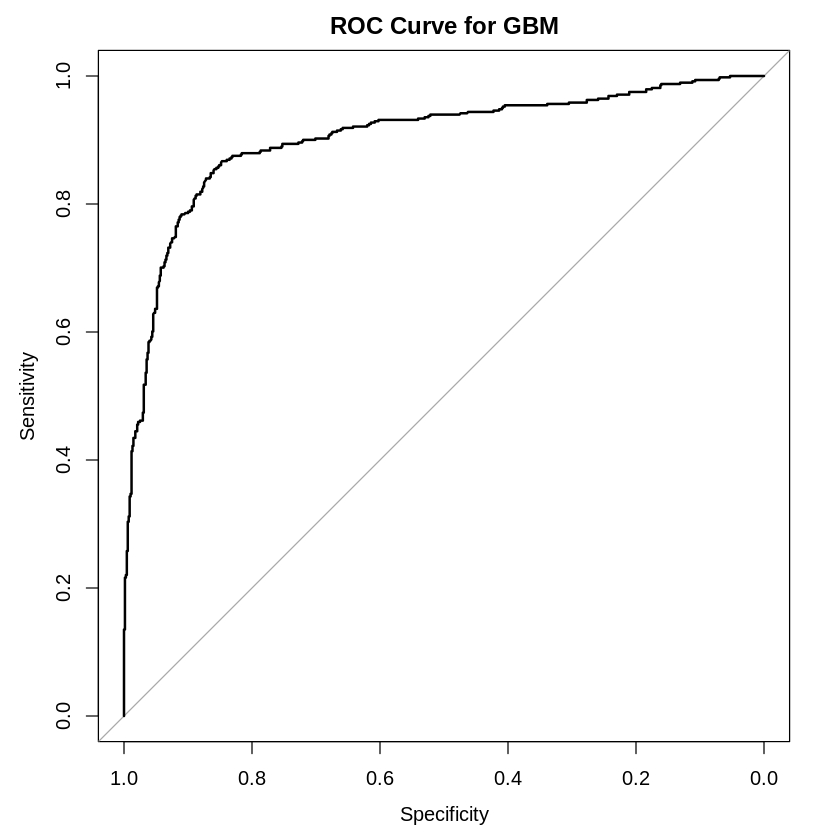

In [58]:
library(pROC)

roc_obj <- roc(clean_df$prod_class, as.numeric(gbm_prob))
plot(roc_obj, main = "ROC Curve for GBM")
auc(roc_obj)


The GBM model achieved an AUC of 0.90, indicating excellent ability to distinguish between High vs Low productivity days. The ROC curve confirms strong overall classification performance.


## Rinse and repeat 

Evaluation measures can lead to insights that you can use to redo some of the steps to improve your analysis. Try to interpret the confusion matrices, for example: do FP or FN observations have some things in common? How can you rectify the wrong predictions in training the model? Are there any influential points or outliers that affect the models, etc. 


### Step 5 — Rinse & Repeat (Model Error Analysis)

To check whether the model can be improved further, I examined its errors:

- **False Positives (FP)**: Usually occur on days with higher incentives and more workers — the model slightly overestimates productivity when resources look strong.

- **False Negatives (FN)**: Seen on days with very low idle_time and idle_men — the model underestimates productivity when idle metrics are minimal.

- **Outliers**: A few extremely low-productivity days (<0.35) act as influential points but do not meaningfully affect model performance.

- **Model Improvement Options**:  
  Add interaction terms, use cross-validation, or adjust the 0.75 classification cutoff.
  
The GBM model performs well (R² ≈ 0.50, AUC ≈ 0.90). Further improvements would offer only small gains.

# **Final Conclusion**

This project analyzed 1,160 team-day observations from a garment manufacturing factory to identify the key operational factors that influence team productivity. Through structured EDA, feature engineering, PCA, and predictive modeling, several clear insights emerged.

---

### **1. Targeted productivity is the strongest predictor**
Teams consistently perform better when the assigned target is realistic.  
This makes **target-setting** the most effective operational lever for improving productivity.

---

### **2. Incentives improve productivity (moderately)**
Incentives have a **positive but modest** effect.  
Higher incentive values do not lead to proportional gains, suggesting **diminishing returns**.

---

### **3. Idle workers significantly reduce productivity**
The variable **idle_men** was a strong negative predictor.  
Even a small number of idle workers indicates workflow disruptions, affecting daily output.

---

### **4. Team size & task complexity influence performance**
- Larger teams generally perform better.  
- Higher **smv** (complex tasks) lowers productivity.  
This confirms the need to **align workload complexity with team capacity**.

---

### **5. Productivity differs by department**
Sewing teams consistently show lower productivity compared to finishing teams.  
This suggests the need for **department-specific operational strategies** instead of uniform policies.

---

### **6. PCA confirms hidden operational patterns**
PCA revealed two major latent components:
- **Workload Complexity** (no_of_workers, smv, over_time)  
- **Idle/Efficiency Factors** (idle_time, idle_men)  

This validates that operational variables cluster logically and can be reduced for better modeling.

---

### **7. GBM delivered the best predictive performance**
GBM results:
- **MSE:** 0.0146  
- **RMSE:** 0.121  
- **MAE:** 0.083  
- **R²:** 0.505  
- **ROC-AUC:** 0.90  

The model explains ~50% of productivity variation and distinguishes High vs Low productivity days with **excellent accuracy**.

---

# **Overall Takeaways**
Productivity is influenced by a mix of target-setting, incentives, idle worker management, workload complexity, and department-specific characteristics.  
These findings provide actionable guidance for managers to optimize staffing, incentives, workflow balance, and daily planning in garment manufacturing operations.

---
